# Práctica 1 — Parte 2: Clasificación (riesgo de enfermedad cardíaca)


## Dependencias

Ejecutar la primera celda de código una vez.


In [1]:
import subprocess
import sys

PIP_DEPS = [
    "numpy>=1.24",
    "pandas>=2.0",
    "matplotlib>=3.7",
    "seaborn>=0.13",
    "scipy>=1.10",
    "scikit-learn>=1.3",
    "xgboost>=2.0",
]

subprocess.check_call([sys.executable, "-m", "pip", "install", *PIP_DEPS])
print("Instalado con:", sys.executable)


Instalado con: d:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\.venv\Scripts\python.exe


## 1. Configuración

Rutas desde la carpeta del proyecto (`datos/`).


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

for _style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    try:
        plt.style.use(_style)
        break
    except OSError:
        continue
sns.set_palette("deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd() if (Path.cwd() / "datos" / "clasificacion" / "HeartDisease.csv").exists() else Path.cwd().parent
DATA_PATH = ROOT / "datos" / "clasificacion" / "HeartDisease.csv"

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("Instala xgboost: pip install xgboost")

print("Datos:", DATA_PATH.resolve())


Datos: D:\Code, 3D, Audio\Coding\GitHub\UNAL-ML\practica_1\datos\clasificacion\HeartDisease.csv


## 2. Datos


In [3]:
df = pd.read_csv(DATA_PATH)
display(df.head())
print(df.shape)
df["target"].value_counts(normalize=True).rename("proporción")


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


(1190, 12)


target
1    0.528571
0    0.471429
Name: proporción, dtype: float64

In [4]:
(
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .round(3)
    .rename("frac_faltantes")
)


age                    0.0
sex                    0.0
chest pain type        0.0
resting bp s           0.0
cholesterol            0.0
fasting blood sugar    0.0
resting ecg            0.0
max heart rate         0.0
exercise angina        0.0
oldpeak                0.0
ST slope               0.0
target                 0.0
Name: frac_faltantes, dtype: float64

## 3. Preprocesamiento


In [5]:
TARGET = "target"

if TARGET not in df.columns:
    raise ValueError("Se esperaba una columna 'target'.")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

feature_names = X.columns.tolist()

preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)
X_train.shape, X_test.shape


((952, 11), (238, 11))

## 4. Modelos y evaluación


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
N_ITER = 24


def eval_classification(name, estimator):
    proba = None
    if hasattr(estimator, "predict_proba"):
        proba = estimator.predict_proba(X_test)[:, 1]
    pred = estimator.predict(X_test)
    out = {
        "modelo": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    }
    if proba is not None:
        try:
            out["roc_auc"] = roc_auc_score(y_test, proba)
        except ValueError:
            out["roc_auc"] = np.nan
    else:
        out["roc_auc"] = np.nan
    return out


rows = []
fitted = {}

pipe_nb = Pipeline([("prep", preprocess), ("model", GaussianNB())])
search_nb = RandomizedSearchCV(
    pipe_nb,
    param_distributions={"model__var_smoothing": loguniform(1e-12, 1e-6)},
    n_iter=12,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search_nb.fit(X_train, y_train)
fitted["GaussianNB"] = search_nb.best_estimator_
r = eval_classification("GaussianNB", search_nb.best_estimator_)
r["best_params"] = search_nb.best_params_
rows.append(r)

search_specs = [
    (
        "KNeighborsClassifier",
        KNeighborsClassifier(),
        {
            "model__n_neighbors": randint(3, 25),
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    ),
    (
        "SVC",
        SVC(random_state=RANDOM_STATE, probability=True),
        {
            "model__C": loguniform(0.01, 100),
            "model__gamma": ["scale", "auto"] + list(np.logspace(-3, 1, 6)),
            "model__kernel": ["rbf", "poly", "sigmoid"],
        },
    ),
    (
        "MLPClassifier",
        MLPClassifier(
            random_state=RANDOM_STATE,
            max_iter=1200,
            early_stopping=True,
            n_iter_no_change=20,
        ),
        {
            "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64)],
            "model__alpha": loguniform(1e-5, 1e-1),
            "model__learning_rate_init": loguniform(1e-4, 1e-2),
        },
    ),
    (
        "RandomForestClassifier",
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": randint(80, 400),
            "model__max_depth": [None] + list(range(4, 24, 2)),
            "model__min_samples_leaf": randint(1, 10),
            "model__max_features": ["sqrt", "log2", None],
        },
    ),
]

if XGBClassifier is not None:
    search_specs.append(
        (
            "XGBClassifier",
            XGBClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
            {
                "model__n_estimators": randint(80, 500),
                "model__max_depth": randint(3, 12),
                "model__learning_rate": loguniform(0.01, 0.3),
                "model__subsample": uniform(0.6, 0.35),
                "model__colsample_bytree": uniform(0.6, 0.35),
            },
        )
    )

for name, est, param_dist in search_specs:
    pipe = Pipeline([("prep", preprocess), ("model", est)])
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=N_ITER,
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    fitted[name] = search.best_estimator_
    row = eval_classification(name, search.best_estimator_)
    row["best_params"] = search.best_params_
    rows.append(row)

results = pd.DataFrame(rows)
results = results.sort_values("roc_auc", ascending=False, na_position="last").reset_index(
    drop=True
)
results


,modelo,accuracy,precision,recall,f1,roc_auc,best_params
0,KNeighborsClassifier,0.928571,0.950413,0.912698,0.931174,0.976687,"{'model__n_neighbors': 24, 'model__p': 1, 'mod..."
1,RandomForestClassifier,0.911765,0.920000,0.912698,0.916335,0.970380,"{'model__max_depth': 20, 'model__max_features'..."
2,XGBClassifier,0.928571,0.943089,0.920635,0.931727,0.969529,{'model__colsample_bytree': 0.7820238074122338...
3,SVC,0.529412,0.529412,1.000000,0.692308,0.960636,"{'model__C': 0.0629064429458615, 'model__gamma..."
4,MLPClassifier,0.878151,0.888000,0.880952,0.884462,0.935162,"{'model__alpha': 0.00021618942406574428, 'mode..."
5,GaussianNB,0.840336,0.860656,0.833333,0.846774,0.903061,{'model__var_smoothing': 1.7670169402947963e-10}


## 5. Gráficos


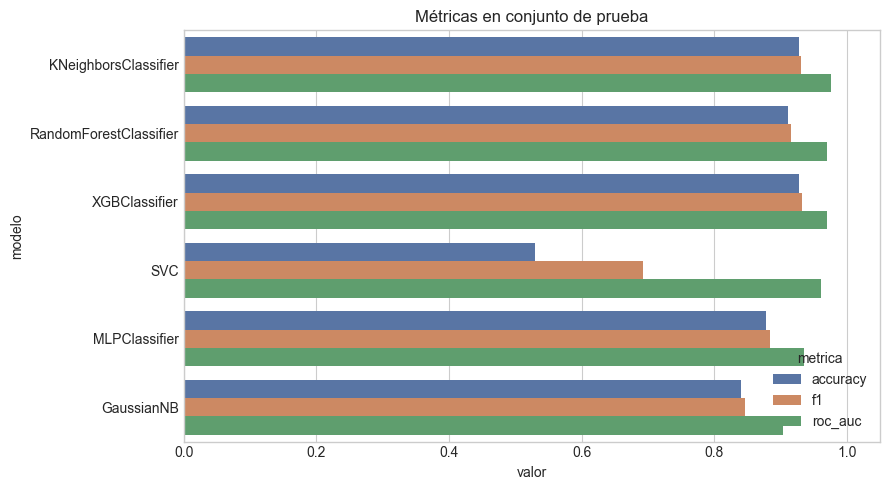

In [7]:
plot_df = results[["modelo", "accuracy", "f1", "roc_auc"]].melt(
    id_vars="modelo", var_name="metrica", value_name="valor"
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_df, y="modelo", x="valor", hue="metrica", ax=ax)
ax.set_title("Métricas en conjunto de prueba")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()


              precision    recall  f1-score   support

           0      0.906     0.946     0.926       112
           1      0.950     0.913     0.931       126

    accuracy                          0.929       238
   macro avg      0.928     0.930     0.928       238
weighted avg      0.930     0.929     0.929       238



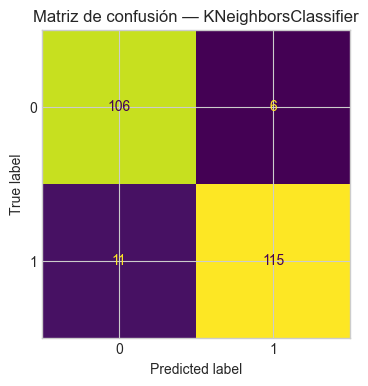

In [8]:
best_name = results.loc[0, "modelo"]
best_model = fitted[best_name]
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred, digits=3))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión — {best_name}")
plt.show()


## 6. Hiperparámetros


In [10]:
for _, r in results.iterrows():
    print(r["modelo"], "->", r["best_params"])


KNeighborsClassifier -> {'model__n_neighbors': 24, 'model__p': 1, 'model__weights': 'distance'}
RandomForestClassifier -> {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__n_estimators': 171}
XGBClassifier -> {'model__colsample_bytree': np.float64(0.7820238074122338), 'model__learning_rate': np.float64(0.06420330336297862), 'model__max_depth': 8, 'model__n_estimators': 270, 'model__subsample': np.float64(0.8947996711082494)}
SVC -> {'model__C': np.float64(0.0629064429458615), 'model__gamma': np.float64(1.584893192461114), 'model__kernel': 'rbf'}
MLPClassifier -> {'model__alpha': np.float64(0.00021618942406574428), 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.0026070247583707684)}
GaussianNB -> {'model__var_smoothing': np.float64(1.7670169402947963e-10)}


In [12]:
top = results.iloc[0]
second = results.iloc[1] if len(results) > 1 else None

print(f"Mejor modelo (criterio de búsqueda: ROC-AUC en CV): {top['modelo']}")
print(
    f"  ROC-AUC (prueba): {top['roc_auc']:.4f}  |  Accuracy: {top['accuracy']:.4f}  |  F1: {top['f1']:.4f}"
)

if second is not None and pd.notna(second.get("roc_auc")):
    delta_auc = top["roc_auc"] - second["roc_auc"]
    print(f"\nSegundo en ranking: {second['modelo']}")
    print(
        f"  ROC-AUC (prueba): {second['roc_auc']:.4f}  |  Accuracy: {second['accuracy']:.4f}  |  F1: {second['f1']:.4f}"
    )
    print(f"\nVentaja en ROC-AUC (mejor − segundo): {delta_auc:+.4f}")

svc_row = results.loc[results["modelo"] == "SVC"]
if not svc_row.empty:
    s = svc_row.iloc[0]
    print(
        f"\nSVC (referencia): ROC-AUC={s['roc_auc']:.4f}, accuracy={s['accuracy']:.4f}, F1={s['f1']:.4f}"
    )


Mejor modelo (criterio de búsqueda: ROC-AUC en CV): KNeighborsClassifier
  ROC-AUC (prueba): 0.9767  |  Accuracy: 0.9286  |  F1: 0.9312

Segundo en ranking: RandomForestClassifier
  ROC-AUC (prueba): 0.9704  |  Accuracy: 0.9118  |  F1: 0.9163

Ventaja en ROC-AUC (mejor − segundo): +0.0063

SVC (referencia): ROC-AUC=0.9606, accuracy=0.5294, F1=0.6923


## 7. Resultados

El ranking se construyó optimizando **ROC-AUC** en validación cruzada; en el conjunto de prueba, **KNeighborsClassifier** encabeza la tabla con **ROC-AUC ≈ 0.977**, **accuracy ≈ 0.93** y **F1 ≈ 0.93**, es decir, buen equilibrio entre acierto global y calidad en la clase positiva. **RandomForestClassifier** queda segundo en AUC (≈ 0.970) con métricas también altas; la ventaja del ganador en AUC es modesta (**≈ +0.006** frente al segundo), lo que indica varios modelos de frontera no lineal muy competitivos en este conjunto tabular ya escalado.

**XGBClassifier** alcanza valores muy similares a KNN en accuracy y F1 (≈ 0.93), pero queda por detrás en AUC en esta corrida concreta. Las **barras agrupadas** muestran el mismo patrón: KNN, bosque y boosting concentran barras altas y parejas en accuracy, F1 y ROC-AUC, mientras que **MLPClassifier** y **GaussianNB** quedan algo más abajo (NB como baseline razonable con hipótesis más fuerte).

El caso **SVC** merece aparte: **ROC-AUC alta (≈ 0.96)** y a la vez **accuracy baja (≈ 0.53)**. Eso suele ocurrir cuando la búsqueda prioriza el orden de los scores y `predict` aplica un **umbral fijo 0,5** sobre probabilidades calibradas con Platt: los scores pueden separar bien las clases (AUC) pero el umbral etiqueta mal casi siempre una clase. En un uso real habría que **ajustar el umbral** con validación o priorizar otra métrica (F1, recall del positivo) si el coste de falsos negativos importa.

La **matriz de confusión** del mejor modelo (KNN) resume el comportamiento en prueba: muchos aciertos en la diagonal (TN ≈ 106, TP ≈ 115), pocos falsos positivos (≈ 6) y algo más de **falsos negativos (≈ 11)** frente a la clase 1, coherente con el `classification_report` (precision/recall equilibrados en torno a 0.91–0.95). Los datos no mostraron **valores faltantes** en las variables numéricas usadas, lo que simplifica la imputación en el pipeline.
